In [1]:
import pandas as pd
#Import CSV
df = pd.read_csv("StudentsPerformance.csv")

#Check Rows And Columns
df.shape

(1000, 8)

In [2]:
#Checking Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [3]:
#Columns
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [4]:
#Descirbing the data frame
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
#Head 
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [6]:
#Data Cleaning
df.columns = df.columns.str.replace(" ","_")
df.columns = df.columns.str.replace("/","_")
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [7]:
#Average Score
df['average_score']= (df['math_score'] + df['reading_score'] + df['writing_score'])/3
print(df[['math_score', 'reading_score', 'writing_score', 'average_score']].head())

   math_score  reading_score  writing_score  average_score
0          72             72             74      72.666667
1          69             90             88      82.333333
2          90             95             93      92.666667
3          47             57             44      49.333333
4          76             78             75      76.333333


In [8]:
#Check their is any null value 
print(df.isnull().sum())

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
average_score                  0
dtype: int64


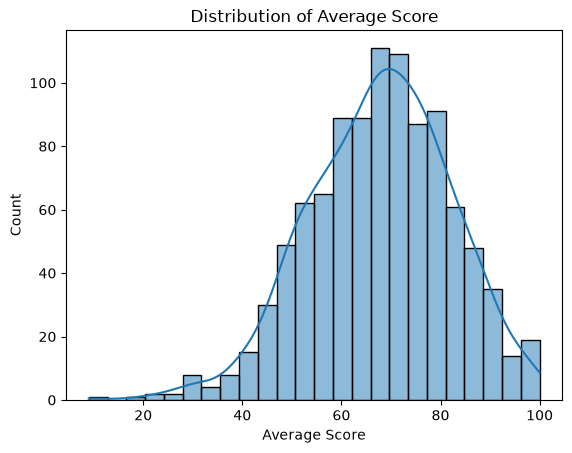

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#histogram
sns.histplot(data=df, x='average_score', kde=True)
plt.title('Distribution of Average Score')
plt.xlabel('Average Score')
plt.ylabel('Count')
plt.show()

**Defination :**
- The chart is left-skewed, meaning most students scored above average, while a smaller group of students scored much lower, pulling the tail to the left

In [10]:
# Average Score By Test Prepartion Course
print(df.groupby("test_preparation_course")["average_score"].mean())

test_preparation_course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64


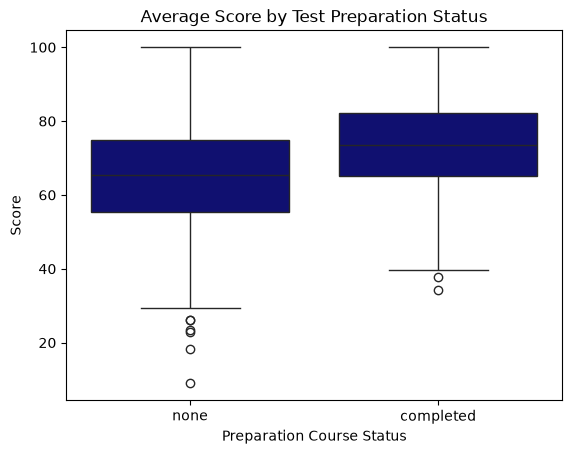

In [11]:
#Box Plot
sns.boxplot(data=df, x='test_preparation_course', y="average_score", color ="navy")
plt.title('Average Score by Test Preparation Status')
plt.xlabel('Preparation Course Status')
plt.ylabel('Score')
plt.show()

**Defination :**
- Above Chart Shows That Student Who Have Comleted Their Test Prepartion Coures They Have Avarage Score 72.67% And Those Are who Not Completed They have 65.03% ,The Difference Between Them is 7.64%.

In [12]:
print(df.groupby("parental_level_of_education")["average_score"].mean())

parental_level_of_education
associate's degree    69.569069
bachelor's degree     71.923729
high school           63.096939
master's degree       73.598870
some college          68.476401
some high school      65.108007
Name: average_score, dtype: float64


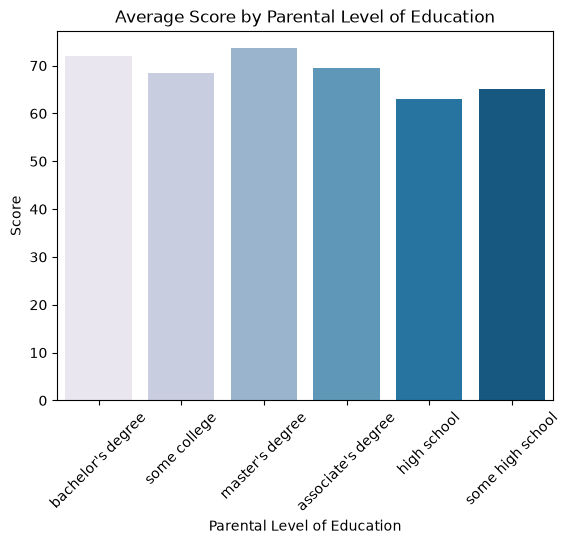

In [13]:
sns.barplot(data=df, x='parental_level_of_education', y="average_score",
            hue='parental_level_of_education', palette="PuBu", legend=False, errorbar=None)
plt.title('Average Score by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.xticks(rotation=45) 
plt.ylabel('Score')
plt.show()

**Key finding:**
- Average score generally increases with parental education level, from Some High 65.10% for students with parents who have some high school education, up to 73.60% for students whose parents hold a master's degree
- This suggests a link between parental educational background and student performance

In [14]:
#Checking Average Score by Gender ,lunch, Race Ethnicity
columns_to_check = ['gender', 'lunch', 'race_ethnicity']

for col in columns_to_check:
    print(f"--- Average score by {col} ---")
    print(df.groupby(col)['average_score'].mean())
    print()

--- Average score by gender ---
gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

--- Average score by lunch ---
lunch
free/reduced    62.199061
standard        70.837209
Name: average_score, dtype: float64

--- Average score by race_ethnicity ---
race_ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: average_score, dtype: float64



In [15]:
print(df.groupby(['lunch', 'test_preparation_course'])['average_score'].mean())

lunch         test_preparation_course
free/reduced  completed                  67.755725
              none                       58.949405
standard      completed                  75.505140
              none                       68.302233
Name: average_score, dtype: float64


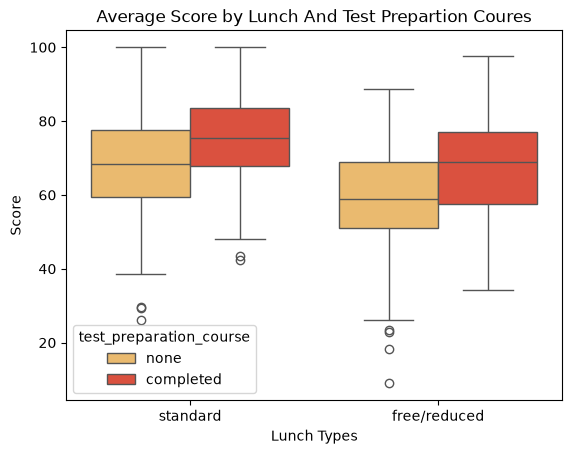

In [22]:
#Avrage Score By Lunch And Test Prepartion Coures
sns.boxplot(data=df, x='lunch', y="average_score" , hue='test_preparation_course',palette="YlOrRd")
plt.title('Average Score by Lunch And Test Prepartion Coures')
plt.xlabel('Lunch Types')
plt.ylabel('Score')
plt.show()

**Key finding:**
- Students with free/reduced lunch and no test prep scored lowest on average (58.95), while students with standard lunch and completed test prep scored highest (75.51) - a gap of 16.5 points between the extremes
- Test prep raises scores for free/reduced lunch students by about 8.8 points, slightly more than the 7.2 point boost seen for standard lunch students
- This suggests test preparation may help narrow the gap linked to economic background, rather than widen it
  

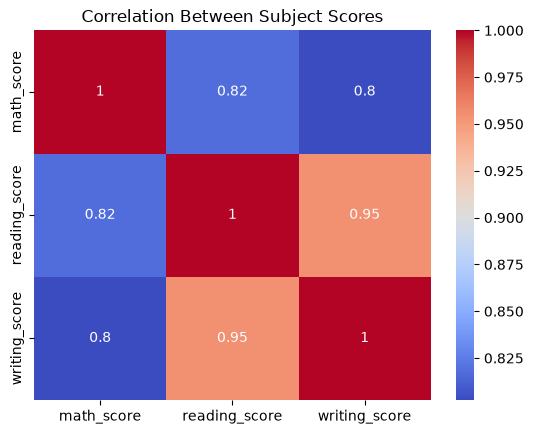

In [17]:
#heatmap 
correlation_matrix = df[['math_score', 'reading_score', 'writing_score']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Subject Scores')
plt.show()

**Key finding:**
- Reading and writing scores are highly correlated (0.95), meaning students who do well in one nearly always do well in the other
- Math shows a comparatively weaker relationship with both reading (0.82) and writing (0.80), suggesting math ability is somewhat more independent of general language performance

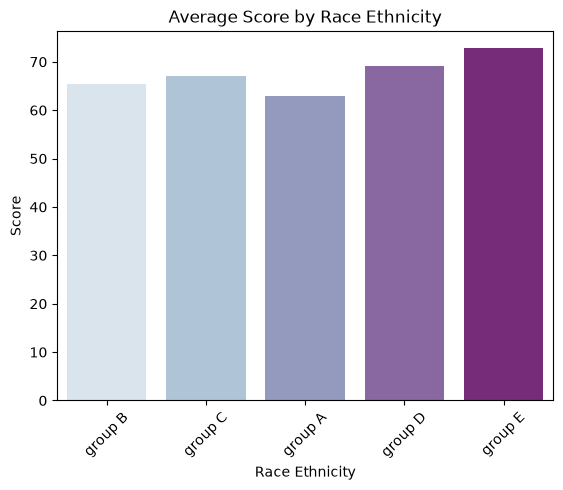

In [18]:
#Avrage Score By Race Ethnicity
sns.barplot(data= df , x ="race_ethnicity",y="average_score",
           hue="race_ethnicity", palette="BuPu", legend=False, errorbar=None)
plt.title('Average Score by Race Ethnicity')
plt.xlabel('Race Ethnicity')
plt.xticks(rotation=45) 
plt.ylabel('Score')
plt.show()

**Key finding:**
- Average score rises steadily across groups, from 62.99 (group A) to 72.75 (group E), a spread of about 9.8 points
- Unlike some other factors, this increase is fairly consistent step by step across groups rather than concentrated in just one or two


  

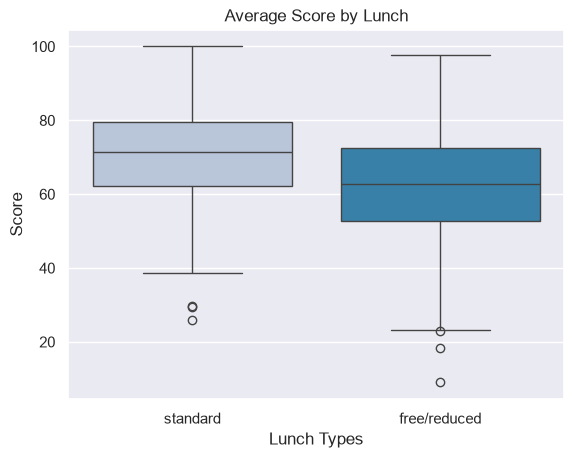

In [40]:
#avg Score By lunch
sns.boxplot(data=df, x='lunch', y="average_score",hue="lunch",palette="PuBu")
plt.title('Average Score by Lunch')
plt.xlabel('Lunch Types')
plt.ylabel('Score')
plt.show()


**Key finding:**
- Students with standard lunch averaged 70.84, compared to 62.20 for free/reduced lunch - a gap of about 8.6 points
- This is the largest single-factor gap found in the dataset, and likely reflects broader socioeconomic differences tied to lunch assistance eligibility
  